# Clarke (αβ) & Park (dq) transforms illustrated

Illustration of Clarke (αβ) & Park (dq) transforms of three phase signals (typically voltages or currents), in the following cases:

- with perfectly balanced signals or with imperfections:
    - imbalance
    - harmonics
    - negative sequence
- with well matched dq reference frame speed or too slow or too fast

Usage: to select a given signal, run last the cell with desired signal definition

Left to be done:

- wrap the code into one function to make an interactive version

Pierre Haessig, April 2026

*Intructions: run all the cells below (Menu "Run / Run All Cells" or use, for each cell, the Run button with the triangle icon ▶️)*

In [1]:
try: # Install ipywidgets package in JupyterLite, if run in JupyterLite
    import piplite
    await piplite.install(['ipywidgets'])
except ImportError:
    pass

In [2]:
import numpy as np
from numpy import pi, cos, sin
sq = np.sqrt
import matplotlib.pyplot as plt

## Generate three-phase grid signal

horizontal range (time/phase) to be plotted: 

In [131]:
Nper = 1 # nb of periods
Npts = Nper*301 # Nb of points

f = 50 # Hz, true signal frequency
f_est = 50 # Hz, estimated signal frequency, for Park transform

t = np.linspace(0, Nper/f, Npts) # Nper periods at frequency f
θ_ini = 0 # rad, initial signal phase
θ = 2*pi*f*t + θ_ini # true signal phase
θ_est = 2*pi*f_est*t # estimated signal phase, for use in Park transform

Perfectly balanced, positive sequence signals:

In [117]:
name = 'balanced three-phase signal'
fname = 'balanced'

va = cos(θ)
vb = cos(θ - 2*pi/3)
vc = cos(θ - 4*pi/3)

Perfectly balanced, but negative sequence signals (i.e. negative frequency):

In [134]:
name = 'balanced, but negative sequence signal'
fname = 'balanced_neg'

va = cos(θ)
vb = cos(θ + 2*pi/3)
vc = cos(θ + 4*pi/3)

Imbalanced signal

In [62]:
ai = 0.1

va = cos(θ)
vb = (1+ai)*cos(θ - 2*pi/3)
vc = (1-ai)*cos(θ - 4*pi/3) # variant: ac = 1+ai

name = f'{ai:.0%} amplitude imbalance'
fname = f'imbalanced-a{ai*100:.0f}'

Harmonic perturbation

In [94]:
n = 2
n_name = f'{n}th' if n>3 else ('3rd' if n==3 else '2nd')
an = 0.1
θn = 0

va = cos(θ)          + an*cos(n*θ + θn)
vb = cos(θ - 2*pi/3) + an*cos(n*θ + θn -2*n*pi/3)
vc = cos(θ - 4*pi/3) + an*cos(n*θ + θn -4*n*pi/3)

name = f'{an:.0%} {n_name} harmonic'
fname = f'harmonic-{n}-{an*100:.0f}'

## Apply transforms

$$ v_{\alpha \beta 0}(t) = T_{\alpha \beta 0} \times v_{abc}(t)  $$
   
with transformation matrix $T_{\alpha \beta}$:

$$ T_{\alpha \beta 0} = 
   {\frac 23}{\begin{bmatrix}
       1 & -{\frac 12}               & -{\frac 12}\\
       0 &  {\frac {{\sqrt {3}}}{2}} & -{\frac {{\sqrt {3}}}{2}} \\
       \frac 12 & \frac 12 & \frac 12
   \end{bmatrix}} $$

In [135]:
print('selected signal:', name)
v_abc = np.vstack((va,vb,vc))

selected signal: balanced, but negative sequence signal


### Clarke transform

In [136]:
# Clarke
Tαβ0 = 2./3 * np.array(
    [[1,     -1/2,     -1/2],
     [0,  sq(3)/2, -sq(3)/2],
     [1/2,    1/2,      1/2]])

Apply transform at each instant:

In [137]:
v_αβ0 = Tαβ0 @ v_abc
v_αβ0.shape

(3, 301)

### Parke transform

rotation of the αβ vector by angle $-\hat{\theta}$

In [138]:
if f_est < f:
    park_name = f'dq frame too slow ({f_est}/{f})'
    park_fname = f'dq_{f_est}-{f}'
elif f_est > f:
    park_name = f'dq frame too fast ({f_est}/{f})'
    park_fname = f'dq_{f_est}-{f}'
else:
    park_name = ''
    park_fname = ''

print('dq transform case:', park_name if park_name else 'dq frame speed matched')

dq transform case: dq frame speed matched


In [139]:
v_dq0 = np.zeros_like(v_abc)

for k in range(Npts):
    ck = cos(θ_est[k])
    sk = sin(θ_est[k])
    R = np.array([
        [ ck, sk, 0],
        [-sk, ck, 0],
        [  0,  0, 1],
    ])
    v_dq0[:,k] = R @ v_αβ0[:,k]

## Plot

Colors:

In [140]:
c = {
    'a': 'tab:blue',
    'b': 'tab:orange',
    'c': 'tab:green',
    'α': 'tab:blue',
    'β': 'tab:red',
    '0': 'tab:gray',
    'd': 'tab:blue',
    'q': 'tab:red',
}

In [141]:
vec_slice = np.round(np.arange(4)*Npts/4).astype(int)
vec_slice

array([  0,  75, 150, 226])

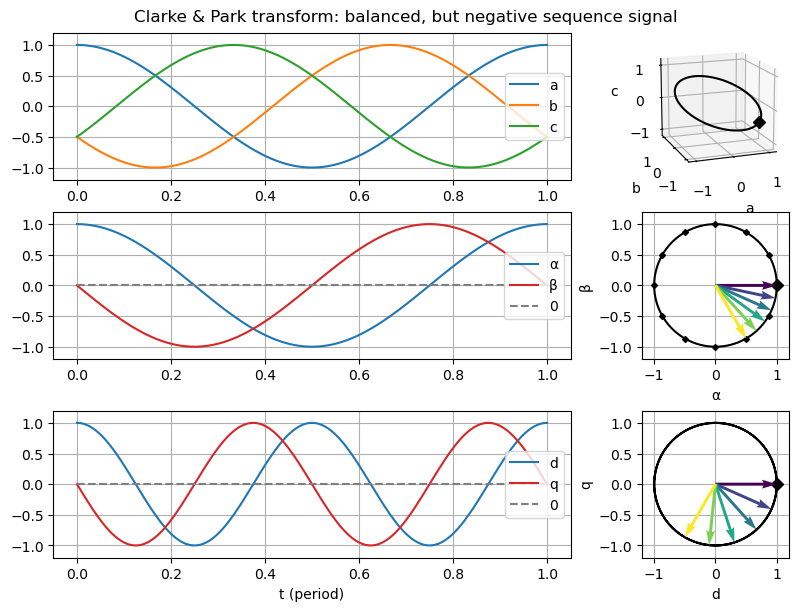

In [142]:
fig = plt.figure(figsize=(8,6), layout='constrained')

# signal range:
v_max = 1.2
v_range = (-v_max, v_max)

# Plot layout: 3 x 2
# - first column: time domain
# - second column: spatial domain

spec = fig.add_gridspec(3, 2, width_ratios=[3, 1])

ax_abct = fig.add_subplot(spec[0, 0])
ax_αβ0t = fig.add_subplot(spec[1, 0])
ax_dq0t = fig.add_subplot(spec[2, 0])

ax_abc3d = fig.add_subplot(spec[0, 1], projection='3d')
ax_αβ = fig.add_subplot(spec[1, 1])
ax_dq = fig.add_subplot(spec[2, 1])

ax_t = [ax_abct, ax_αβ0t, ax_dq0t]
ax_vec = [ax_αβ, ax_dq]

# Time domain plots

x = t*f # t, period
ax_abct.plot(x, v_abc[0,:], label='a', color=c['a'])
ax_abct.plot(x, v_abc[1,:], label='b', color=c['b'])
ax_abct.plot(x, v_abc[2,:], label='c', color=c['c'])

ax_αβ0t.plot(x, v_αβ0[0,:], label='α', color=c['α'])
ax_αβ0t.plot(x, v_αβ0[1,:], label='β', color=c['β'])
ax_αβ0t.plot(x, v_αβ0[2,:], '--', label='0', color=c['0'])

ax_dq0t.plot(x, v_dq0[0,:], label='d', color=c['d'])
ax_dq0t.plot(x, v_dq0[1,:], label='q', color=c['q'])
ax_dq0t.plot(x, v_dq0[2,:], '--', label='0', color=c['0'])

ax_dq0t.set_xlabel('t (period)')


# Spatial domain

ax_abc3d.plot(v_abc[0,:], v_abc[1,:], v_abc[2,:], color='k')
ax_abc3d.plot(v_abc[0,0], v_abc[1,0], v_abc[2,0], 'D', color='k')

ax_αβ.plot(v_αβ0[0, :], v_αβ0[1, :], color='k')
ax_αβ.plot(v_αβ0[0, ::25], v_αβ0[1, ::25], 'D', ms=3, color='k')
ax_αβ.plot(v_αβ0[0, 0], v_αβ0[1, 0], 'D', color='k')

def plot_vec_slice(ax, vx, vy, vec_slice):
    orig = np.zeros(len(vx))
    ax.quiver(orig[vec_slice], orig[vec_slice], vx[vec_slice], vy[vec_slice], x[vec_slice],
                   angles='xy', scale=1, scale_units='xy', zorder=3, width=0.02)

vec_slice = np.round(np.arange(4)*Npts/4).astype(int)
vec_slice = np.arange(6)*10
plot_vec_slice(ax_αβ, v_αβ0[0,:], v_αβ0[1,:], vec_slice)

ax_dq.plot(v_dq0[0, :], v_dq0[1, :], color='k')
ax_dq.plot(v_dq0[0, 0], v_dq0[1, 0], 'D', color='k')
plot_vec_slice(ax_dq, v_dq0[0,:], v_dq0[1,:], vec_slice)

ax_abc3d.set(
    aspect='equal',
    xlabel='a', ylabel='b', zlabel='c',
    xlim=v_range, ylim=v_range, zlim=v_range
)
ax_abc3d.view_init(elev=15, azim=-110)

ax_αβ.set(
    aspect='equal',
    xlabel='α', ylabel='β',
    xlim=v_range, ylim=v_range,
)
ax_dq.set(
    aspect='equal',
    xlabel='d', ylabel='q',
    xlim=v_range, ylim=v_range,
)

for axi in ax_t+ax_vec:
    axi.grid()
for axi in ax_t:
    axi.set_ylim(v_range)
    axi.legend(loc='center right')

park_name_ = f' ({park_name})' if park_name else ''
fig.suptitle(f'Clarke & Park transform: {name}' + park_name_)
fig.savefig(fname+park_fname+'.png', dpi=300);
#fig.tight_layout()